This is a demo of the capabilities of MPHvect to qualitatively map persistence daigrams to vectors in ell_1. MPHvect is an implementation of the methods described in "A Schauder Basis for Multiparameter Persistence and Persitsence Variants": Peter Bubenik & Zachariah Ross, 2025. In this theory, we use a Schauder basis of functionals on the upper-left half of the plane to map persistence diagrams to vectors. In this example, we use this vectorizing method to distinguish between two classes of data sampling.

In [ ]:
#install necessary packages
!pip install git+https://github.com/ZachTRoss/MPHvect.git
#while not absolutely necessary, numba drastically decreases runtime for MPHvect
!pip install numba
!pip install persim
!pip install nbformat

  Cloning https://github.com/ZachTRoss/MPHvect.git to /tmp/pip-req-build-izbvlsr2
  Running command git clone --filter=blob:none --quiet https://github.com/ZachTRoss/MPHvect.git /tmp/pip-req-build-izbvlsr2
  Resolved https://github.com/ZachTRoss/MPHvect.git to commit e9225adde49d8224f4078d57a9abb2a195e3ff9a
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 43.3 MB/s eta 0:00:00
  Created wheel for MPHvect: filename=MPHvect-0.1.0-py3-none-any.whl size=10003 sha256=64dbf4af2f4fe87c92127f4dbacd8a784a5a9f3d9b3158ebe76a6355ceb23050
  Stored in directory: /tmp/pip-ephem-wheel-cache-61favd_i/wheels/16/a7/37/f7d75b3a040fb4073e527243d839bd02415932158eb3594cb9
Successfully built MPHvect
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.6/48.6 kB 2.5 MB/s eta 0:00:00
  Created wheel for hopcroftkarp: filename=hopcroftkarp-1.2.5-py2.py3-none-any.whl size=18104 sha256=603fe0be3c996128c2c5d4f00c93545736b08aa92f3245dd

In [ ]:
import numba
import random
import sys, math
import gudhi as gd
from persim import PersLandscapeApprox

from MPHvect.method import*
from MPHvect.SVM_functions import*



We now define sampling methods for generating data points in R^2.

In [ ]:


def generate_unif_points_on_disc(num_points, not_scaled=True):
  list_x=[]
  list_y=[]
  for i in range(num_points):
    in_disk=False
    while in_disk==False:
      x = np.random.uniform(-1, 1)
      y = np.random.uniform(-1,1)
      if x**2 + y**2 <= 1:
        in_disk=True
        list_x.append(x)
        list_y.append(y)
  return np.array([list_x,list_y]).T



def sample_unit_disk_Gaussian(n, sigma=0.4):

  points_x=[]
  points_y=[]
  while len(points_x)<n:

    x = np.random.normal(loc=0.0, scale=sigma)
    y = np.random.normal(loc=0.0, scale=sigma)

    if np.linalg.norm([x,y])<=1:
      points_x.append(x)
      points_y.append(y)

  return np.array([points_x, points_y]).T


def plot_two_point_sets(array_1, array_2, point_size=6, ax_limit=None, name_1="Point Set 1", name_2="Point Set 2"):
    fig, axes = plt.subplots(1, 2)

    axes[0].scatter(array_1[:, 0], array_1[:, 1], s=point_size)
    axes[1].scatter(array_2[:, 0], array_2[:, 1], s=point_size)

    if ax_limit==None:

      all_x = np.concatenate([array_1[:, 0], array_2[:, 0]])
      all_y = np.concatenate([array_1[:, 1], array_2[:, 1]])

      x_min, x_max = all_x.min(), all_x.max()
      y_min, y_max = all_y.min(), all_y.max()

      axis_min=min(x_min, y_min)-0.1*(max(x_max,y_max)-min(x_min, y_min))
      axis_max=max(x_max, y_max)+0.1*(max(x_max,y_max)-min(x_min, y_min))

    if ax_limit is not None:
      axis_min=-0.1* ax_limit
      axis_max=1.1*ax_limit

    for ax, title in zip(axes, [name_1, name_2]):
        ax.set_xlim(axis_min, axis_max)
        ax.set_ylim(axis_min, axis_max)
        ax.set_title(title)
        ax.set_aspect('equal', adjustable='box')

    plt.tight_layout()
    plt.show()

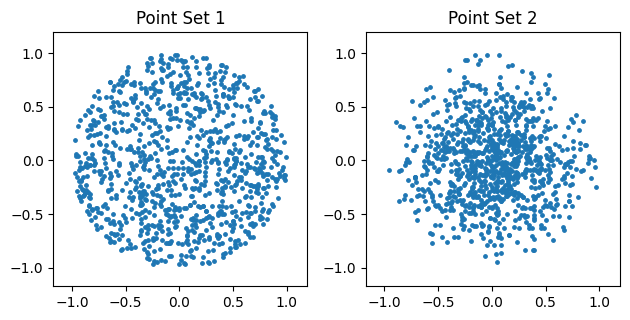

In [ ]:
#Plot examples from each sampling method
points_1=generate_unif_points_on_disc(1000)
points_2=sample_unit_disk_Gaussian(1000)
plot_two_point_sets(points_1, points_2)

In [ ]:
#create 100 of each sampling

iterations=100
n_points=1000
Class_unif=[]
Class_Ga=[]
for i in range(iterations):
  Class_unif.append(generate_unif_points_on_disc(n_points))
  Class_Ga.append(sample_unit_disk_Gaussian(n_points))


Now we compare the persitence diagrams (in homology degree 1) of these two sampling methods.

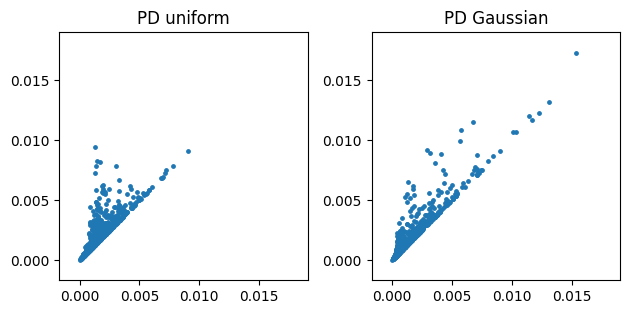

In [ ]:

def compute_PD(points):
  alpha = gd.AlphaComplex(points=points)
  st = alpha.create_simplex_tree()
  st.persistence()
  H1 = st.persistence_intervals_in_dimension(1)

  return H1




my_PD_unif=compute_PD(Class_unif[0])

my_PD_Ga=compute_PD(Class_Ga[0])

plot_two_point_sets(my_PD_unif, my_PD_Ga, name_1="PD uniform", name_2="PD Gaussian")


In [ ]:
#compute the persistence diagram in degree 1 for each of the data samplings above
PD_unif=[]
PD_Ga=[]

for i in range(iterations):
  PD_unif.append(compute_PD(Class_unif[i]))
  PD_Ga.append(compute_PD(Class_Ga[i]))

  sys.stdout.write(f"\rCompleted {i+1}/{iterations}")
  sys.stdout.flush()
print()

Completed 100/100


In [ ]:
#The toy sampling methods we are using generate persistence diagrams which have slightly different total persistence.
#MPHvect maps persistence diagrams to a vector in ell_1, for which the first coordinate is a constant multiple of total persistence.
#So to make things harder, we will normalize each persistence diagram to have total persistence =1

def normalize_by_tot_pers(list_of_pds):
  new_list=[]
  for pd in list_of_pds:
    total=0
    for x,y in pd:
      total+=y-x
    for i in range(len(pd)):
      pd[i]=[pd[i][0]/total, pd[i][1]/total]
    new_list.append(pd)
  return new_list


PD_unif=normalize_by_tot_pers(PD_unif)
PD_Ga=normalize_by_tot_pers(PD_Ga)

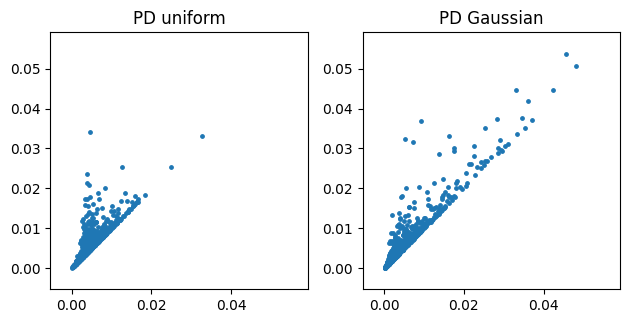

1.0000000000000002
0.9999999999999998


In [ ]:
#Example
index=10

my_pd_unif=PD_unif[index]
my_pd_Ga=PD_Ga[index]

plot_two_point_sets(my_pd_unif, my_pd_Ga, name_1="PD uniform", name_2="PD Gaussian")

total_unif=np.sum([x[1]-x[0] for x in my_pd_unif])
total_Ga=np.sum([x[1]-x[0] for x in my_pd_Ga])

print(total_unif)
print(total_Ga)

In [ ]:
#MPHvect uses functionals on the upper-left half of the unit square.
#While this method works for unnormalized persistence diagrams in this space, it is more efficient to normalize the persistence diagrams to "fill out" the unit square.
#This avoids having large numbers of functionals that evaluate to 0 on the persistence diagrams: i.e. avoids having vectors with many coordinates =0.

def get_norm_val(pd):
  new_pd=pd[np.argsort(-pd[:,1]+pd[:,0])]


  cutoff=10
  new_new_pd=new_pd[:int(cutoff)]
  norm_val= np.max(new_new_pd[:,1])


  return norm_val

def get_overall_norm_val(PDs):
  union=np.vstack(PDs)
  return get_norm_val(union)


def normalize_pd(pd, norm_val=None):
  if norm_val is None:
    norm_val=get_norm_val(pd)
  new_pd=(norm_val**(-1))*0.9*pd
  return new_pd







In [ ]:
#These are the values we chose to represent the "relevant upper bound" of points of each class of the persistence diagrams. Note that these values are not necessarily the maximum death value of all poitns of the diagrams in each class.
#Rather, these values are the maximum death values of some of the most persistent points.

val_unif=get_overall_norm_val(PD_unif)
val_Ga=get_overall_norm_val(PD_Ga)
norm_val=max(val_unif, val_Ga)
print(val_unif)
print(val_Ga)

0.03819654103433259
0.07660134753006732


In [ ]:
PD_unif=[normalize_pd(pd, norm_val) for pd in PD_unif]
PD_Ga=[normalize_pd(pd, norm_val) for pd in PD_Ga]

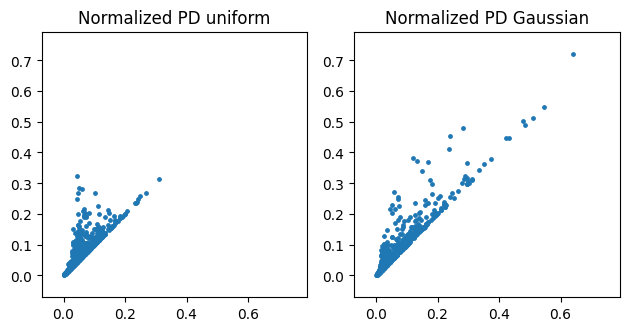

In [ ]:
plot_two_point_sets(PD_unif[0], PD_Ga[0], name_1="Normalized PD uniform", name_2="Normalized PD Gaussian")

Now that we've normalize our 200 persistence diagrams to have equal total persistence and to fill out the unit square (or at least the upper left half of it), we are ready to map these persistence diagrams to vectors. First, we will try the traditional method of persistence landscapes, which yield positive results. Then we will illustrate that MPHvect yields similar results.

In [ ]:
Land_unif=[]
Land_Ga=[]

pd1=PD_unif[0]
pd2=PD_Ga[0]


xmin = 0
xmax = 1


#xs = np.linspace(xmin, xmax, 500)

num_layers=2


for i in range(iterations):
  pers_land_unif=PersLandscapeApprox(dgms=[PD_unif[i]], hom_deg=0, start=0, stop=xmax, num_steps=500).values
  pers_land_Ga=PersLandscapeApprox(dgms=[PD_Ga[i]], hom_deg=0, start=0, stop=xmax, num_steps=500).values

  land_k_layers_unif=pers_land_unif[:num_layers]
  land_k_layers_Ga=pers_land_Ga[:num_layers]

  Land_unif.append(land_k_layers_unif.flatten())
  Land_Ga.append(land_k_layers_Ga.flatten())

  sys.stdout.write(f"\rCompleted {i+1}/{iterations}")
  sys.stdout.flush()
print()


Completed 100/100


In [ ]:
#Note the length of these vectors (500 values for each layer)
print(len(Land_unif[0]))
print(len(Land_Ga[0]))

1000
1000


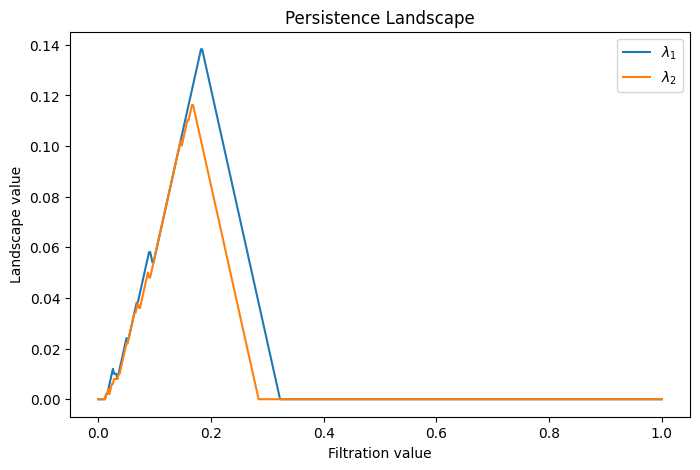

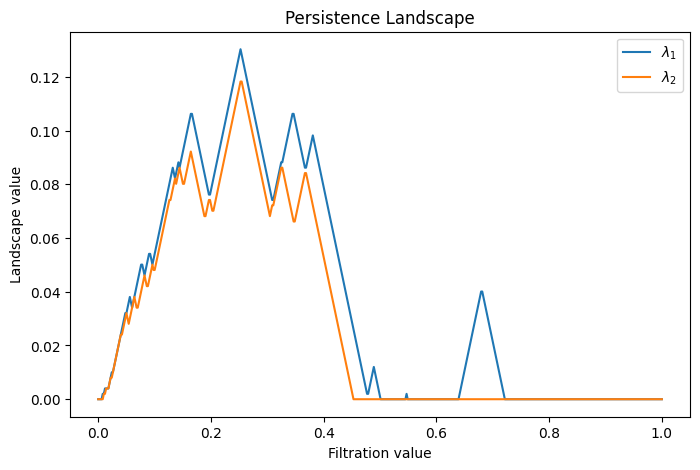

In [ ]:
def plot_landscape(L, resolution=500, num_layers=10, bmin=0, dmax=1):
    L_reshaped = L.reshape(num_layers, resolution)

    t = np.linspace(bmin,dmax, resolution)

    plt.figure(figsize=(8,5))
    for k in range(num_layers):
        plt.plot(t, L_reshaped[k], label=f"$\\lambda_{k+1}$")

    plt.xlabel("Filtration value")
    plt.ylabel("Landscape value")
    plt.title("Persistence Landscape")

    plt.legend()
    plt.show()

plot_landscape(Land_unif[0], num_layers=num_layers, dmax=xmax)
plot_landscape(Land_Ga[0], num_layers=num_layers, dmax=xmax)

Observed accuracy: 1.0000
Permutation p-value: 0.0000


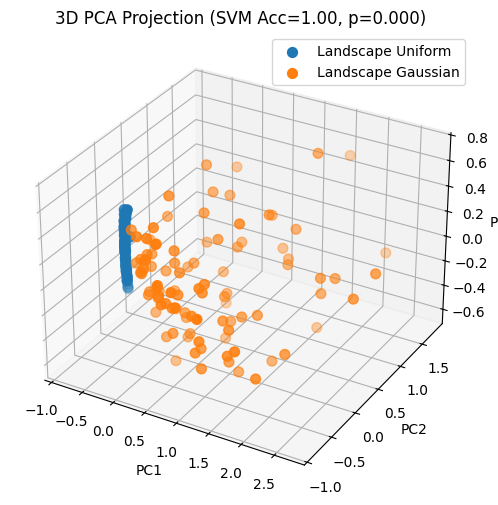

In [ ]:
#We now attempt to classify these vectors using Support Vector Machine (SVM).
#We also do a permutation test with 1000 permutations and calculate a p-value. Finally, we plot the PCA projection onto 3 components.

do_SVM_and_PCA(Land_unif, Land_Ga, name_1='Landscape Uniform', name_2='Landscape Gaussian')


Now let us attempt the same classification using MPHvect.

In [ ]:
#This function defines the parameters for our chosen subset of the Schauder basis induced by refinements
#of the Coxeter Freudenthal Kuhn triangulation on the upper left half of the plane
#The inputs: dim is the number of parameters for which we are using persistence homology (i.e. 1-parameter persistence): max layer is the maximal number of refinements we take of the Coxeter Freudenthal Kuhn triangulation
#we take in order to define our subset of the associated Schauder Basis. min_layer is the first refinement we consider in our construction of such a subset of funcitonals.
n_list, p_list=collect_vertices(dim=1,max_layer=3,min_layer=1)




In [ ]:
#We now use this chosen subset to map each persistnece diagram to a vector
MPH_vec_unif=[]
MPH_vec_Ga=[]

for i in range(iterations):
  points=PD_unif[i]
  mults=[1 for _ in range(len(points))]
  MPH_vec_unif.append(vectorize_fast(n_list, p_list, points, mults ))

  points=PD_Ga[i]
  mults=[1 for _ in range(len(points))]
  MPH_vec_Ga.append(vectorize_fast(n_list, p_list, points, mults ))

  sys.stdout.write(f"\rCompleted {i+1}/{iterations}")
  sys.stdout.flush()
print()

Completed 100/100


In [ ]:
print(len(MPH_vec_unif[0]))
print(len(MPH_vec_Ga[0]))

36
36


Observed accuracy: 1.0000
Permutation p-value: 0.0000


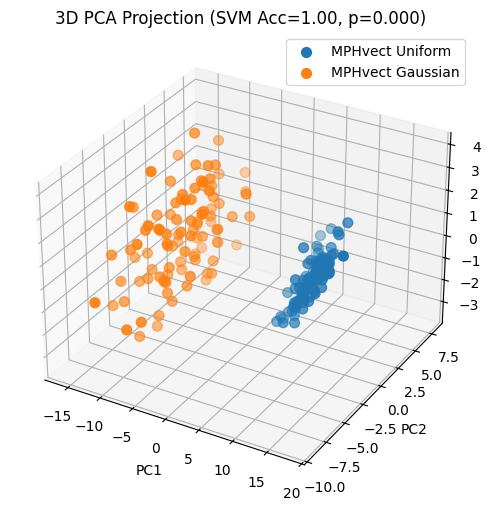

In [ ]:
#We now attempt to classify these vectors using Support Vector Machine (SVM).
#We also do a permutation test with 1000 permutations and calculate a p-value. Finally, we plot the PCA projection onto 3 components.
do_SVM_and_PCA(MPH_vec_unif, MPH_vec_Ga, name_1='MPHvect Uniform', name_2='MPHvect Gaussian')
